# Лабораторная работа 2
## Выполнил Улискин Даниил Евгеньевич
## Группа ФИТ-241


## Вариант 3




In [1]:
%matplotlib inline
import time
import random
import matplotlib.pyplot as plt

## № 1 (2 балла)

Реализуйте или найдите реализации двух сортировок: сортировка выбором и быстрая сортировка. Проведите вычислительные
эксперименты и нарисуйте графики, показывающие зависимость времени выполнения двух алгоритмов от размера входных данных.
Рассмотрите три варианта входных данных:
1. Список случайных чисел
2. Отсортированный список
3. Отсортированный в обратную сторону список

Для каждого из вариантов должен быть свой график зависимости.

In [2]:
def selection_sort(a):
    a = a[:]                      # работаем с копией
    n = len(a)
    for i in range(n - 1):
        m = i                     # индекс минимального элемента в a[i:]
        for j in range(i + 1, n):
            if a[j] < a[m]:
                m = j
        a[i], a[m] = a[m], a[i]
    return a


def quick_sort(a):
    if len(a) <= 1:
        return a
    pivot = a[len(a) // 2]
    less = [x for x in a if x < pivot]
    equal = [x for x in a if x == pivot]
    greater = [x for x in a if x > pivot]
    return quick_sort(less) + equal + quick_sort(greater)



test = [random.randint(0, 100) for _ in range(50)]
assert selection_sort(test) == sorted(test)
assert quick_sort(test) == sorted(test)
print("Сортировки работают правильно")

Сортировки работают правильно


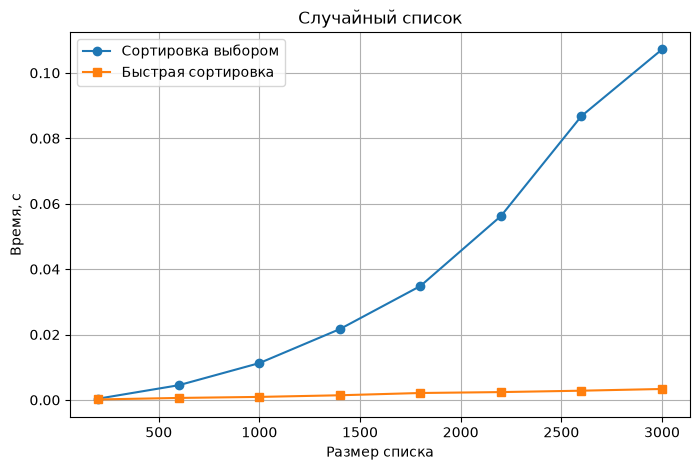

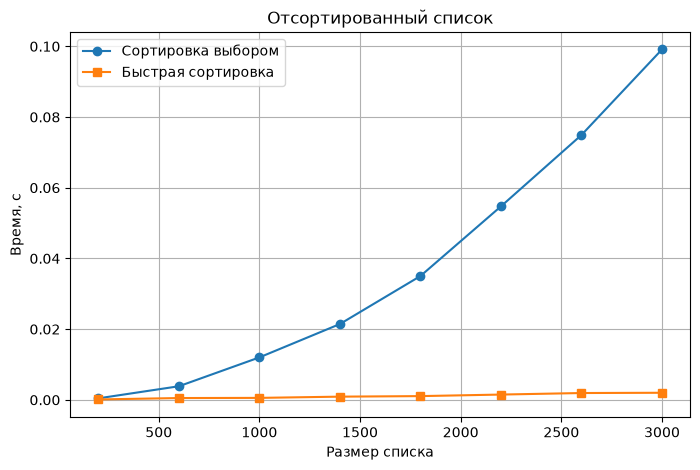

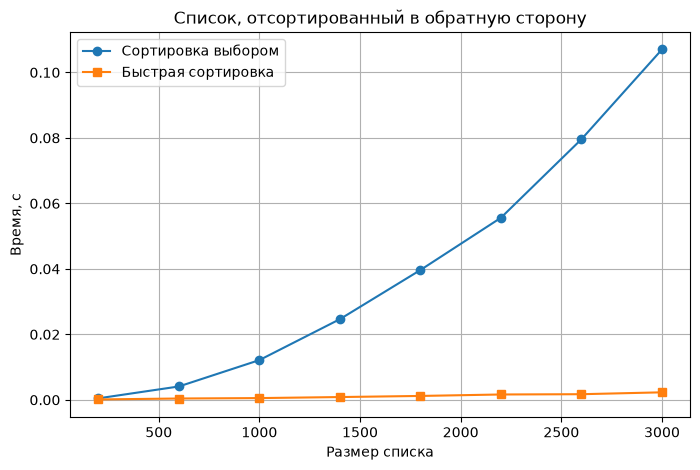

In [ ]:
sizes = list(range(200, 3001, 400))     # размеры списков
repeats = 3                             


def measure(sort_func, data):
    total = 0
    for _ in range(repeats):
        start = time.perf_counter()
        sort_func(data)
        total += time.perf_counter() - start
    return total / repeats


def make_data(kind, n):
    if kind == "random":
        return [random.randint(0, 10**6) for _ in range(n)]
    if kind == "sorted":
        return list(range(n))
    return list(range(n, 0, -1))        # reversed


kinds = [("random", "Случайный список"),
         ("sorted", "Отсортированный список"),
         ("reversed", "Список, отсортированный в обратную сторону")]

for kind, title in kinds:
    t_sel, t_quick = [], []
    for n in sizes:
        data = make_data(kind, n)
        t_sel.append(measure(selection_sort, data))
        t_quick.append(measure(quick_sort, data))
    plt.figure(figsize=(8, 5))
    plt.plot(sizes, t_sel, "o-", label="Сортировка выбором")
    plt.plot(sizes, t_quick, "s-", label="Быстрая сортировка")
    plt.title(title)
    plt.xlabel("Размер списка")
    plt.ylabel("Время, с")
    plt.grid(True)
    plt.legend()
    plt.show()

**Вывод.** Сортировка выбором делает ~n² сравнений при любых данных, поэтому её время растёт квадратично
и почти не зависит от того, как упорядочен список. Быстрая сортировка в среднем работает за n·log n
и на всех трёх видах данных оказывается гораздо быстрее.

## № 2 (2 балла)

Ряд Трибоначчи начинается с тройки 0, 0, 1, а каждое следующее число равно сумме трёх предыдущих. Числа нумеруются с 0.

Напишите функцию `tribonacci(n)`, которая принимает в себя номер числа и возвращает n-ое число Трибоначчи.
Функция должна быть рекурсивной. При решении данной задачи не используйте циклы.
Укажите базовый и рекурсивный случаи функции.

In [ ]:
def tribonacci(n):
    if n == 0 or n == 1:
        return 0
    if n == 2:
        return 1
    return tribonacci(n - 1) + tribonacci(n - 2) + tribonacci(n - 3)


print([tribonacci(i) for i in range(12)])

[0, 0, 1, 1, 2, 4, 7, 13, 24, 44, 81, 149]


**Базовый случай:** `n = 0` и `n = 1` → 0, `n = 2` → 1.

**Рекурсивный случай:** `tribonacci(n) = tribonacci(n-1) + tribonacci(n-2) + tribonacci(n-3)` при `n >= 3`.

## № 3 (2 балла)

Для задачи вашего варианта напишите подходящую рекурсивную функцию. При решении задачи не используйте циклы.
Укажите базовый и рекурсивный случаи вашей функции.

**3 вариант.** Напишите рекурсивную функцию `recursive_two(some_list)`, которая возвращает кортеж из двух значений –
наибольший элемент списка `some_list` и второй наибольший его элемент.

In [5]:
def recursive_two(some_list):
    if len(some_list) == 2:
        a, b = some_list
        return (a, b) if a >= b else (b, a)
    first = some_list[0]
    largest, second = recursive_two(some_list[1:])
    if first > largest:
        return (first, largest)
    if first > second:
        return (largest, first)
    return (largest, second)


print(recursive_two([3, 9, 1, 7, 5]))      
print(recursive_two([1, 2]))              
print(recursive_two([5, 5, 2]))            
print(recursive_two([-4, -1, -8, -2]))     

(9, 7)
(2, 1)
(5, 5)
(-1, -2)




**Базовый случай:** в списке 2 элемента – возвращаем их в порядке (большее, меньшее).

**Рекурсивный случай:** берём первый элемент, для остального списка (`some_list[1:]`) рекурсивно находим пару
(наибольший, второй наибольший) и вставляем первый элемент в эту пару на своё место.

## № 4 (2 балла)

Числа Фибоначчи - это последовательность, которая вычисляется по рекуррентному соотношению F(N) = F(N-1) + F(N-2),
где F0 = 0, а F1 = 1. Числа Люка задаются примерно так же: L(N) = L(N-1) + L(N-2), где L0 = 2, а L1 = 1.
Пользуясь стандартным рекурсивным подходом, напишите две функции - `fibonacci(n)` и `lucas(n)`, которые будут
вычислять n-е число Фибоначчи и Люка соответственно. Измерьте время, которое требуется для вычисления FN и LN
вплоть до N = 40. Если ваш компьютер достаточно быстрый, N стоит увеличить для повышения точности, а если слишком
медленный - уменьшить, чтобы измерения заканчивались за приемлемое время.

Затем напишите функцию `fib_with_lucas(n)` и вспомогательную к ней, `lucas_with_fib(n)`, пользуясь такими свойствами
этих последовательностей:
* `fib_with_lucas(n)` – если поделить n нацело пополам и взять i = n // 2, а j = n - i, то
  F(n) = F(i + j) = (F(i)·L(j) + F(j)·L(i)) // 2;
* `lucas_with_fib(n)` – в свою очередь, L(N) = F(N-1) + F(N+1).

Сравните быстродействие `fibonacci()` и `fib_with_lucas()`. Постройте график.

In [ ]:
def fibonacci(n):
    if n < 2:                                   
        return n
    return fibonacci(n - 1) + fibonacci(n - 2) 


def lucas(n):
    if n == 0:                                  
        return 2
    if n == 1:                                  
        return 1
    return lucas(n - 1) + lucas(n - 2)          


def fib_with_lucas(n):
    if n < 2:
        return n
    i = n // 2
    j = n - i
    # F(i+j) = (F(i)*L(j) + F(j)*L(i)) / 2
    return (fib_with_lucas(i) * lucas_with_fib(j) + fib_with_lucas(j) * lucas_with_fib(i)) // 2


def lucas_with_fib(n):
    if n == 0:
        return 2
    if n == 1:
        return 1
    if n == 2:
        return 3
    # L(n) = F(n-1) + F(n+1)
    return fib_with_lucas(n - 1) + fib_with_lucas(n + 1)



for k in range(25):
    assert fibonacci(k) == fib_with_lucas(k), k
    assert lucas(k) == lucas_with_fib(k), k
print("Все функции дают одинаковые результаты")
print([fibonacci(k) for k in range(10)])
print([lucas(k) for k in range(10)])

Все функции дают одинаковые результаты
[0, 1, 1, 2, 3, 5, 8, 13, 21, 34]
[2, 1, 3, 4, 7, 11, 18, 29, 47, 76]


n = 40:  fibonacci = 10.054 c,  lucas = 12.261 c,  fib_with_lucas = 0.000297 c


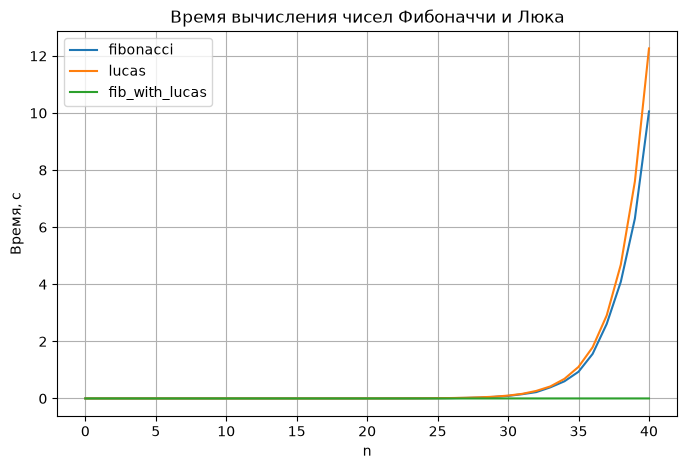

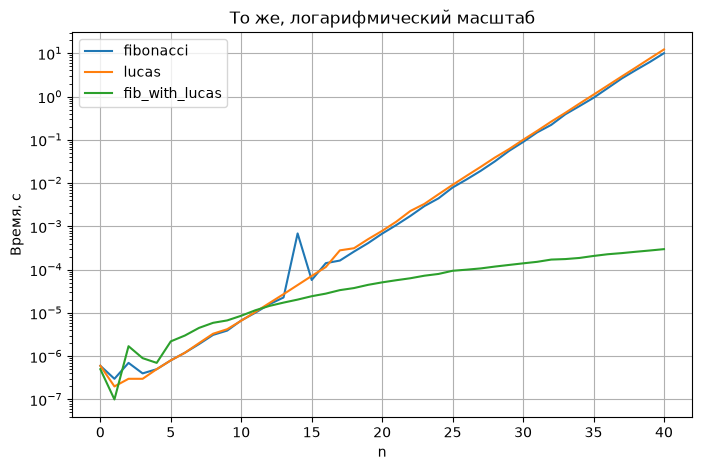

In [7]:
N = 40        

def timeit(func, n):
    start = time.perf_counter()
    func(n)
    return time.perf_counter() - start


ns = list(range(N + 1))
t_fib = [timeit(fibonacci, n) for n in ns]
t_lucas = [timeit(lucas, n) for n in ns]
t_fwl = [timeit(fib_with_lucas, n) for n in ns]

print(f"n = {N}:  fibonacci = {t_fib[-1]:.3f} c,  lucas = {t_lucas[-1]:.3f} c,  "
      f"fib_with_lucas = {t_fwl[-1]:.6f} c")

plt.figure(figsize=(8, 5))
plt.plot(ns, t_fib, label="fibonacci")
plt.plot(ns, t_lucas, label="lucas")
plt.plot(ns, t_fwl, label="fib_with_lucas")
plt.title("Время вычисления чисел Фибоначчи и Люка")
plt.xlabel("n")
plt.ylabel("Время, с")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.semilogy(ns, [max(t, 1e-7) for t in t_fib], label="fibonacci")
plt.semilogy(ns, [max(t, 1e-7) for t in t_lucas], label="lucas")
plt.semilogy(ns, [max(t, 1e-7) for t in t_fwl], label="fib_with_lucas")
plt.title("То же, логарифмический масштаб")
plt.xlabel("n")
plt.ylabel("Время, с")
plt.grid(True)
plt.legend()
plt.show()

**Вывод.** Обычные `fibonacci` и `lucas` работают за экспоненциальное время (каждый вызов порождает два новых, одни и те же
значения считаются много раз). `fib_with_lucas` каждый раз уменьшает `n` примерно вдвое, поэтому число вызовов растёт
только как степенная функция от `n`, и она работает на несколько порядков быстрее.

## № 5 (3 балла)

Хорошим примером для иллюстрации рекурсивных алгоритмов являются задачи рисования фракталов. Ниже программа, которая
при помощи модуля turtle рисует фрактальное дерево. Запустите программу и разберитесь в ее коде. Попробуйте поменять
параметры при вызове функции `tree` и внутри нее.

Последовательно измените программу для рисования рекурсивного дерева по следующим пунктам:
1. Измените толщину ветвей, чтобы при уменьшении branchLen линии становились тоньше.
2. Измените цвет ветвей таким образом, чтобы самые короткие ветви окрашивались как листья.
3. Измените угол поворота черепахи, чтобы каждая ветвь поворачивалась произвольным образом в некотором диапазоне.
   Например, выбирайте угол между 15-ю и 45-ю градусами.
4. Измените рекурсивную часть branchLen, чтобы каждый раз вычиталось произвольное значение из некоторого диапазона
   вместо некой постоянной величины.

В отчете приведите несколько примеров получившихся деревьев.



### Исходное дерево из задания

In [ ]:
import turtle


def tree(branchLen, t):
    if branchLen > 5:
        t.forward(branchLen)
        t.right(20)
        tree(branchLen - 15, t)
        t.left(40)
        tree(branchLen - 15, t)
        t.right(20)
        t.backward(branchLen)


def main():
    turtle.TurtleScreen._RUNNING = True     
    t = turtle.Turtle()
    myWin = turtle.Screen()
    t.speed(0)
    t.left(90)
    t.up()
    t.backward(100)
    t.down()
    t.color("green")
    tree(75, t)
    myWin.exitonclick()


main()

### Улучшенное дерево 


1. Толщина: `pensize` зависит от `branchLen` – чем короче ветвь, тем тоньше линия.
2. Цвет: длинные ветви коричневые (ствол), короткие (`branchLen <= 25`) – зелёные, как листья.
3. Углы поворота выбираются случайно из диапазона 15–45 градусов.
4. Длина уменьшается на случайную величину от 10 до 20.

In [ ]:
def set_style(t, branchLen):
    # пункт 1: чем короче ветвь, тем тоньше линия
    t.pensize(max(1, branchLen / 8))
    # пункт 2: самые короткие ветви – как листья
    if branchLen <= 25:
        t.color("green")
    else:
        t.color("saddle brown")


def tree_new(branchLen, t_):
    if branchLen > 5:
        set_style(t_, branchLen)
        t_.forward(branchLen)
        # пункт 3: случайные углы
        angle_right = random.randint(15, 45)
        angle_left = random.randint(15, 45)
        t_.right(angle_right)
        # пункт 4: случайное уменьшение длины
        tree_new(branchLen - random.randint(10, 20), t_)
        t_.left(angle_right + angle_left)
        tree_new(branchLen - random.randint(10, 20), t_)
        t_.right(angle_left)
        set_style(t_, branchLen)         
        t_.backward(branchLen)


def draw_tree(start_len=80, seed=None):
    if seed is not None:
        random.seed(seed)
    turtle.TurtleScreen._RUNNING = True
    t = turtle.Turtle()
    win = turtle.Screen()
    t.speed(0)
    t.hideturtle()
    t.left(90)
    t.up()
    t.backward(200)
    t.down()
    tree_new(start_len, t)
    win.exitonclick()


draw_tree(80, seed=1)

In [ ]:
draw_tree(100, seed=7)

In [ ]:
draw_tree(70, seed=42)

## № 6 (3 балла)

При помощи модуля turtle нарисуйте фрактал, указанный в вашем варианте.

**Вариант 3. Кривая Минковского.**


In [ ]:
TURNS = [0, 90, -90, -90, 0, 90, 90, -90]


def minkowski(t, length, n):
    if n == 0:                      
        t.forward(length)
        return
    for turn in TURNS:               
        t.left(turn)
        minkowski(t, length / 4, n - 1)


def draw_minkowski(length=400, depth=3):
    turtle.TurtleScreen._RUNNING = True
    t = turtle.Turtle()
    win = turtle.Screen()
    t.speed(0)
    t.hideturtle()
    t.pensize(1)
    t.color("darkblue")
    t.up()
    t.goto(-length / 2, 0)
    t.down()
    minkowski(t, length, depth)
    win.exitonclick()


draw_minkowski(400, 3)

## № 7 (3 балла)

Найдите или придумайте алгоритм для рисования фрактальных гор. Подсказка: одним из возможных методов будет
использование треугольников.

**Алгоритм (смещение средних точек).**
1. Берём большой треугольник в 3D, вершины которого имеют координаты (x, y, высота).
2. Находим середины трёх сторон и слегка смещаем каждую по высоте на случайную величину. Величина смещения
   пропорциональна длине стороны.
3. Получаем 4 меньших треугольника и повторяем то же самое для каждого, уменьшая размах случайности вдвое.
4. Когда достигнута нужная глубина (базовый случай), рисуем треугольник. Цвет зависит от высоты: низ – зелёный,
   середина – коричневый, вершины – белые (снег).

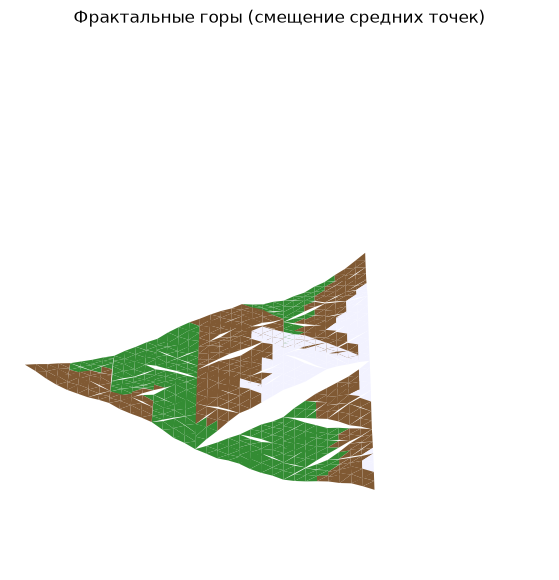

In [13]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

triangles = []     

def midpoint(p, q, roughness):
    dist = ((p[0] - q[0]) ** 2 + (p[1] - q[1]) ** 2) ** 0.5
    x = (p[0] + q[0]) / 2
    y = (p[1] + q[1]) / 2
    z = (p[2] + q[2]) / 2 + random.uniform(-1, 1) * roughness * dist
    return (x, y, z)


def mountain(a, b, c, depth, roughness=0.35):
    if depth == 0:                              
        triangles.append((a, b, c))
        return
    ab = midpoint(a, b, roughness)              
    bc = midpoint(b, c, roughness)
    ca = midpoint(c, a, roughness)
    r = roughness * 0.75                        
    mountain(a, ab, ca, depth - 1, r)
    mountain(ab, b, bc, depth - 1, r)
    mountain(ca, bc, c, depth - 1, r)
    mountain(ab, bc, ca, depth - 1, r)


def height_color(z, zmin, zmax):
    h = (z - zmin) / (zmax - zmin + 1e-9)
    if h < 0.35:
        return (0.2, 0.55, 0.2)       # трава
    if h < 0.7:
        return (0.5, 0.35, 0.2)       # камень
    return (0.95, 0.95, 1.0)          # снег


random.seed(3)
triangles.clear()
mountain((0, 0, 0), (10, 0, 0), (5, 8.66, 0), depth=5)

zs = [p[2] for tri in triangles for p in tri]
zmin, zmax = min(zs), max(zs)
colors = [height_color(sum(p[2] for p in tri) / 3, zmin, zmax) for tri in triangles]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
ax.add_collection3d(Poly3DCollection(triangles, facecolors=colors, edgecolors="none"))
ax.set_xlim(0, 10)
ax.set_ylim(0, 9)
ax.set_zlim(zmin, zmin + 10)
ax.set_box_aspect((10, 9, 4))
ax.view_init(elev=35, azim=-60)
ax.set_axis_off()
ax.set_title("Фрактальные горы (смещение средних точек)")
plt.show()

## № 8 (3 балла)

Решите рекурсивно мини-судоку размером 4x4. Для этого напишите функцию `solve_sudoku(matrix)`, где `matrix` –
целочисленная матрица (список списков).

В мини-судоку числа от 1 до 4 встречаются ровно один раз в каждой вертикали и горизонтали, а также в квадратах 2x2.
Укажите базовый и рекурсивный случаи вашего алгоритма. Пустые места обозначены нулями.

Пример:
```
0000
0020
0100
3004
```
Правильный ответ:
```
2341
1423
4132
3214
```

In [ ]:
def is_valid(matrix, row, col, num):
    for k in range(4):
        if matrix[row][k] == num or matrix[k][col] == num:
            return False
    r0, c0 = (row // 2) * 2, (col // 2) * 2
    for i in range(r0, r0 + 2):
        for j in range(c0, c0 + 2):
            if matrix[i][j] == num:
                return False
    return True


def solve_sudoku(matrix):
    # Ищем первую пустую клетку
    for row in range(4):
        for col in range(4):
            if matrix[row][col] == 0:
                for num in range(1, 5):
                    if is_valid(matrix, row, col, num):
                        matrix[row][col] = num
                        if solve_sudoku(matrix): 
                            return True
                        matrix[row][col] = 0         
                return False                     
    return True


puzzle = [[0, 0, 0, 0],
          [0, 0, 2, 0],
          [0, 1, 0, 0],
          [3, 0, 0, 4]]

if solve_sudoku(puzzle):
    for line in puzzle:
        print("".join(map(str, line)))
else:
    print("Решения нет")

2341
1423
4132
3214


**Базовый случай:** в матрице нет нулей (все клетки заполнены) – судоку решено, возвращаем `True`.

**Рекурсивный случай:** находим первую пустую клетку и по очереди пробуем поставить в неё числа 1–4, которые не
нарушают правила. Если число подходит, рекурсивно решаем оставшуюся часть. Если рекурсия вернула `False`,
клетку очищаем (откат, backtracking) и пробуем следующее число. Если подходящих чисел нет, возвращаем `False`.